# Exploratory Data Analysis & Intro

#### Goal:
  
  1. Investigate top-paying roles and skills in the data science industry.  
  2. Use Python to explore a real-live dataset on job postings.
  3. For job-seekers: use these insights to help find the best job opportunities.  

#### Final Deliverables:
  
  1. Create Jupyter Notebookss (showcasing core skills in Python).
  2. Create a summary page (via README.md) capturing your findings.
  3. Share this project via GitHub & LinkedIn.
  
#### Questions to Answer:
  
  1. What are the most demanded skills for the top 3 most popular data roles?
  2. How are in-demand skills trending for Data Analysts?
  3. How well do jobs and skills pay for Data Analysts?
  4. What is the most optimal skill to learn for Data Analysts? (High Demand AND High Paying) 

## Exploratory Data Analysis for all Data Roles

In [1]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


c:\Users\kichu\anaconda3\envs\python_course\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [27]:
df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()
df_DA_US['job_schedule_type'].value_counts()
df_DA_US[df_DA_US['job_schedule_type'].isin(['Full-time','Contractor','Part-time','Full-time and Part-time','Internship','Temp work','Volunteer'])]['job_schedule_type'].value_counts()

job_schedule_type
Full-time                  57180
Contractor                  6000
Full-time and Part-time      822
Part-time                    770
Internship                   618
Temp work                    305
Volunteer                      8
Name: count, dtype: int64

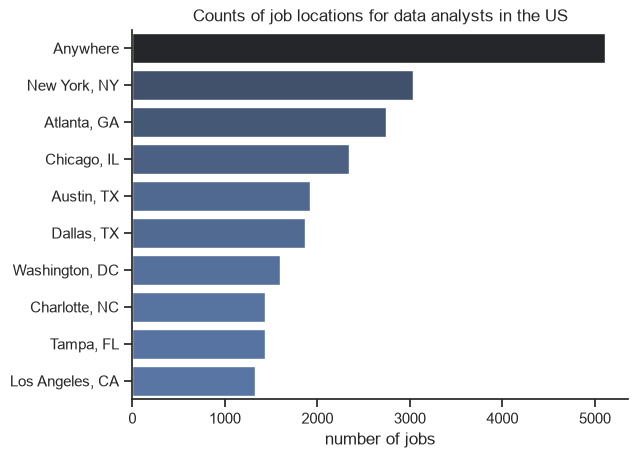

In [16]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data= df_plot,x='count',y='job_location',hue='count',palette='dark:b_r',legend=False)
plt.title('Counts of job locations for data analysts in the US')
plt.xlabel('number of jobs')
plt.ylabel('')
sns.despine()
plt.show()

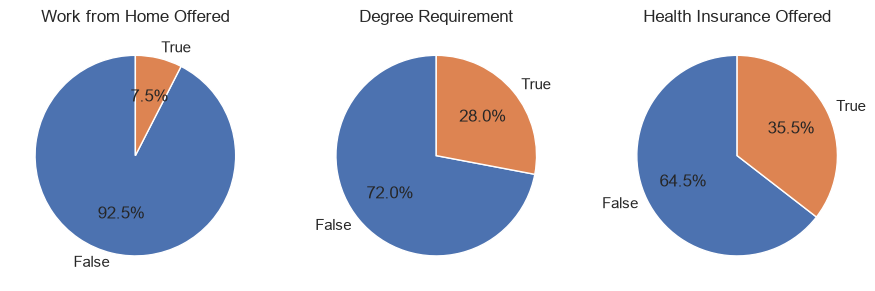

In [17]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()

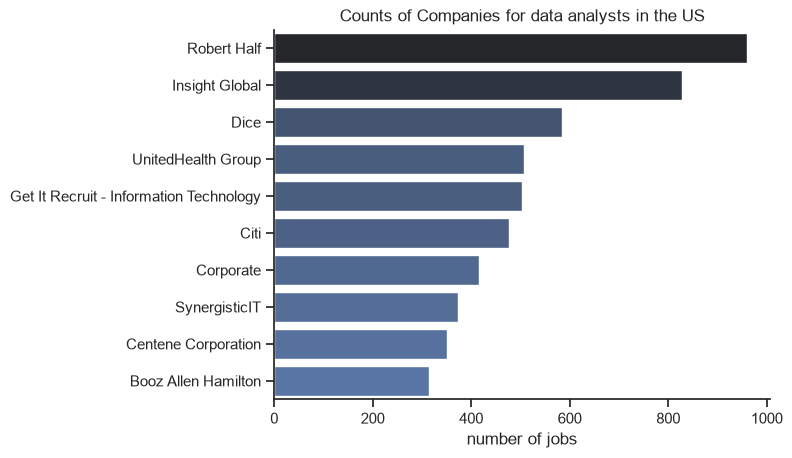

In [18]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data= df_plot,x='count',y='company_name',hue='count',palette='dark:b_r',legend=False)
plt.title('Counts of Companies for data analysts in the US')
plt.xlabel('number of jobs')
plt.ylabel('')
sns.despine()
plt.show()

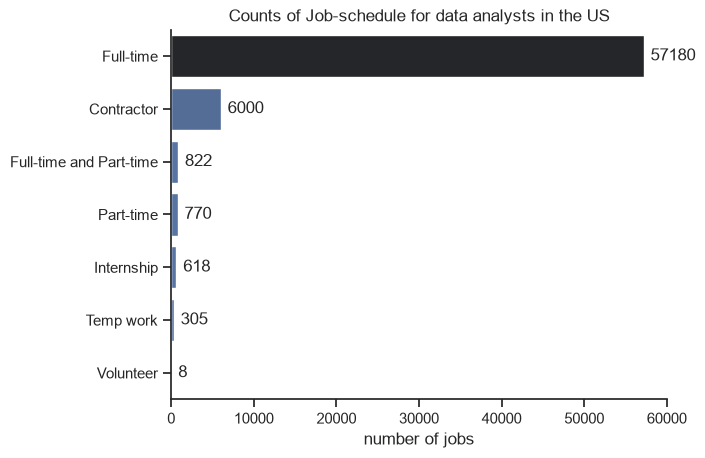

In [32]:

df_plot = df_DA_US[df_DA_US['job_schedule_type'].isin(['Full-time','Contractor','Part-time','Full-time and Part-time','Internship','Temp work','Volunteer'])]['job_schedule_type'].value_counts().to_frame()
sns.set_theme(style='ticks')
ax = sns.barplot(data= df_plot,x='count',y='job_schedule_type',hue='count',palette='dark:b_r',legend=False)
plt.title('Counts of Job-schedule for data analysts in the US')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5)
plt.xlabel('number of jobs')
plt.ylabel('')
sns.despine()
plt.show()